Understanding Image as a Matrix

In [ ]:
from PIL import Image
import numpy as np

Image Colored


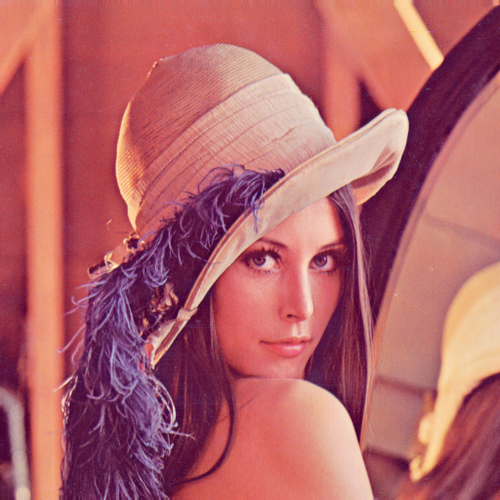

In [ ]:
image_colored = Image.open("/content/image.png")
print("Image Colored")
display(image_colored)

In [ ]:
print("Image Format:",image_colored.format)
print("Image Size:",image_colored.size)
print("Image Mode:",image_colored.mode)

Image Format: PNG
Image Size: (500, 500)
Image Mode: RGB


In [ ]:
width,height = image_colored.size
channels = len(image_colored.getbands())
print("Width:",width)
print("Height:",height)
print("Channels:",channels)
image_size_colored = width*height*channels
print("Image Size:",image_size_colored)

Width: 500
Height: 500
Channels: 3
Image Size: 750000


In [ ]:
image_array_colored = np.array(image_colored)
print("Image Array Colored")
print(image_array_colored.shape)

Image Array Colored
(500, 500, 3)


Image Array Colored
(500, 500, 3)
Red Channel
[[226 225 222 ... 230 221 200]
 [226 225 222 ... 230 221 200]
 [226 225 222 ... 230 221 200]
 ...
 [ 83  84  92 ... 173 171 176]
 [ 81  82  95 ... 178 180 184]
 [ 81  82  96 ... 178 181 185]]


array([[226, 225, 222, ..., 230, 221, 200],
       [226, 225, 222, ..., 230, 221, 200],
       [226, 225, 222, ..., 230, 221, 200],
       ...,
       [ 83,  84,  92, ..., 173, 171, 176],
       [ 81,  82,  95, ..., 178, 180, 184],
       [ 81,  82,  96, ..., 178, 181, 185]], dtype=uint8)
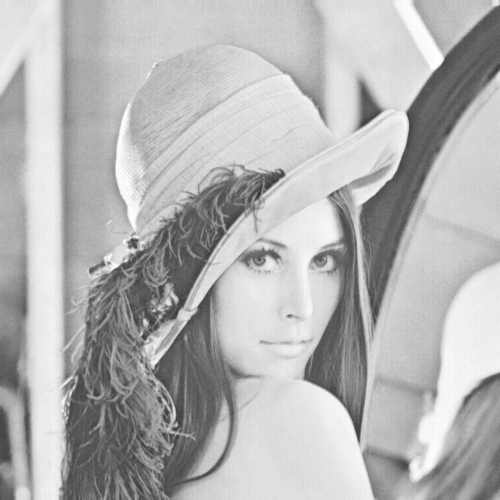

Green Channel
[[137 137 136 ... 148 130  99]
 [137 137 136 ... 148 130  99]
 [137 137 136 ... 148 130  99]
 ...
 [ 17  18  26 ...  72  68  61]
 [ 21  22  31 ...  69  70  73]
 [ 21  22  32 ...  69  71  74]]


array([[137, 137, 136, ..., 148, 130,  99],
       [137, 137, 136, ..., 148, 130,  99],
       [137, 137, 136, ..., 148, 130,  99],
       ...,
       [ 17,  18,  26, ...,  72,  68,  61],
       [ 21,  22,  31, ...,  69,  70,  73],
       [ 21,  22,  32, ...,  69,  71,  74]], dtype=uint8)
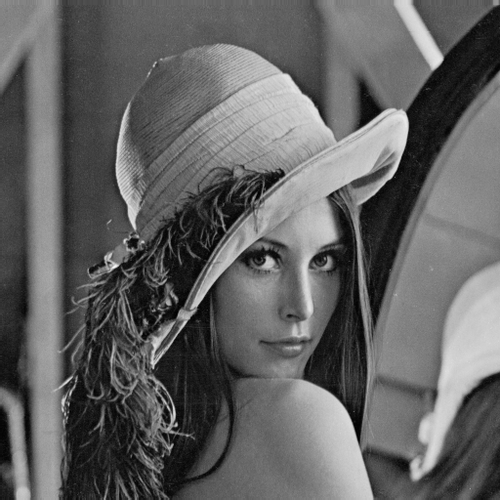

Blue Channel
[[124 125 133 ... 122 110  90]
 [124 125 133 ... 122 110  90]
 [124 125 133 ... 122 110  90]
 ...
 [ 59  59  57 ...  84  76  79]
 [ 57  57  61 ...  78  80  80]
 [ 56  57  62 ...  78  81  81]]


array([[124, 125, 133, ..., 122, 110,  90],
       [124, 125, 133, ..., 122, 110,  90],
       [124, 125, 133, ..., 122, 110,  90],
       ...,
       [ 59,  59,  57, ...,  84,  76,  79],
       [ 57,  57,  61, ...,  78,  80,  80],
       [ 56,  57,  62, ...,  78,  81,  81]], dtype=uint8)
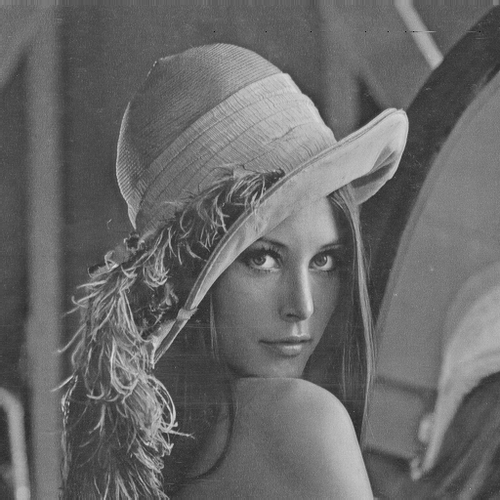

In [ ]:
image_array_colored = np.array(image_colored)
print("Image Array Colored")
print(image_array_colored.shape)

red_channel = image_array_colored[:,:,0]
green_channel = image_array_colored[:,:,1]
blue_channel = image_array_colored[:,:,2]

print("Red Channel")
print(red_channel)
display(red_channel)
print("Green Channel")
print(green_channel)
display(green_channel)
print("Blue Channel")
print(blue_channel)
display(blue_channel)

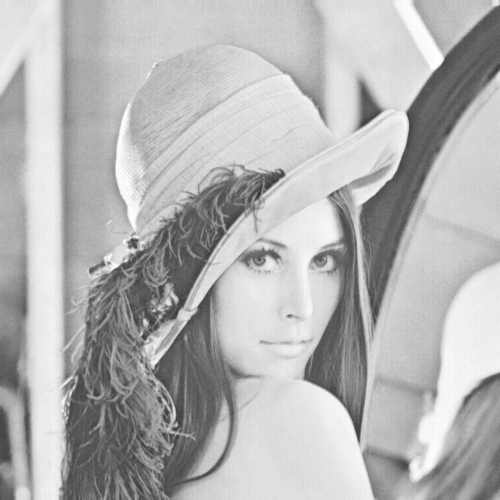

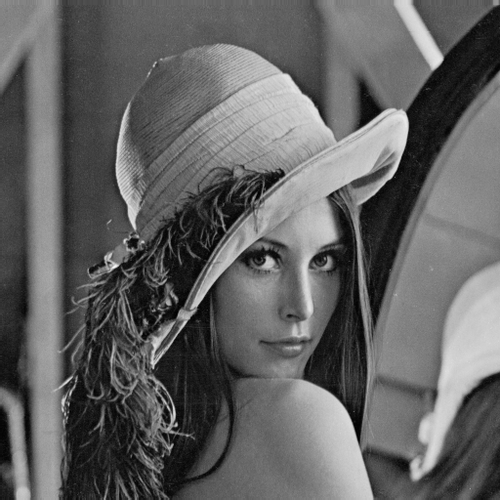

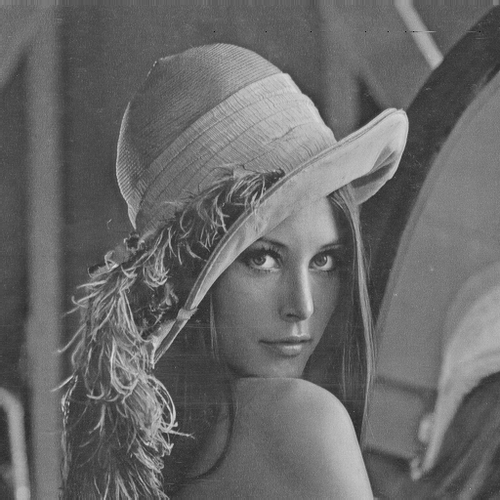

In [ ]:
r , g , b = image_colored . split ()
4 # Display or further process the individual channels
display ( r )
display ( g )
display ( b )

In [ ]:
row_100 = image_array_colored [100 , : , :]
col_50 = image_array_colored [: , 50 , :]
pixel = image_array_colored [10 , 20 , :]
print(pixel)


[223 132 107]


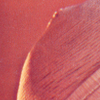

In [ ]:
left = 100
upper = 50
right = 200
lower = 150
cropped_image = image_colored . crop (( left , upper , right ,lower ) )
display ( cropped_image )

In [ ]:
image_array = np . zeros ((100 , 100 , 3) , dtype = np . uint8 )
image_from_array = Image.fromarray ( image_array )
image_from_array.show ()
image_from_array.save ("output_image.png")

PCA for Image Compression

In [ ]:
import matplotlib . pyplot as plt

In [ ]:
image = Image . open ("cameraman.jpeg") . convert ("L")
6 # Convert to NumPy array
image_array = np . array ( image )
8 # Get image dimensions
height , width = image_array . shape
10 # Reshape the image into a 2D array where each row represents a row of pixels
11 # This allows PCA to process each row as an observation and find patterns across pixel intensities
data = image_array . reshape ( height , width )

In [ ]:
mean = np . mean ( data , axis =0)
3 # Subtract mean to center the data
centered_data = data - mean

In [ ]:
cov_matrix = np . cov ( centered_data , rowvar = False )

In [ ]:
eigenvalues , eigenvectors = np . linalg . eigh ( cov_matrix )
3 # Sort eigenvalues and corresponding eigenvectors in descending order
sorted_indices = np . argsort ( eigenvalues ) [:: -1]
eigenvalues = eigenvalues [ sorted_indices ]
eigenvectors = eigenvectors [: , sorted_indices ]

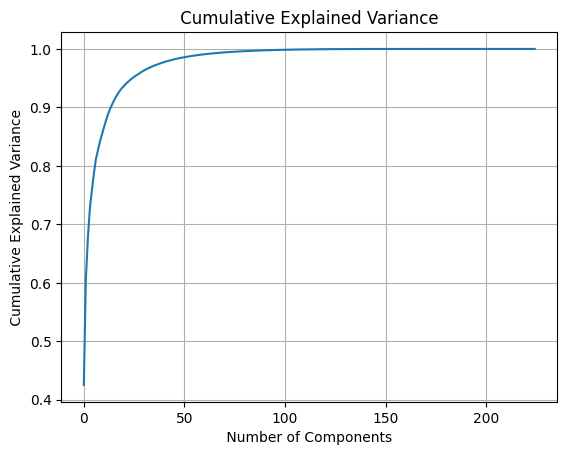

In [ ]:
explained_variance_ratio = eigenvalues / np .sum ( eigenvalues )
plt . plot ( np . cumsum ( explained_variance_ratio ) )
plt . title (" Cumulative Explained Variance ")
plt . xlabel (" Number of Components ")
plt . ylabel (" Cumulative Explained Variance ")
plt . grid ( True )
plt . show ()

In [ ]:
k = 50 # Choose k principal components
components = eigenvectors [: , : k ]

In [ ]:
compressed_data = np . dot ( centered_data , components )

In [ ]:
decompressed_data = np . dot ( compressed_data , components . T ) + mean

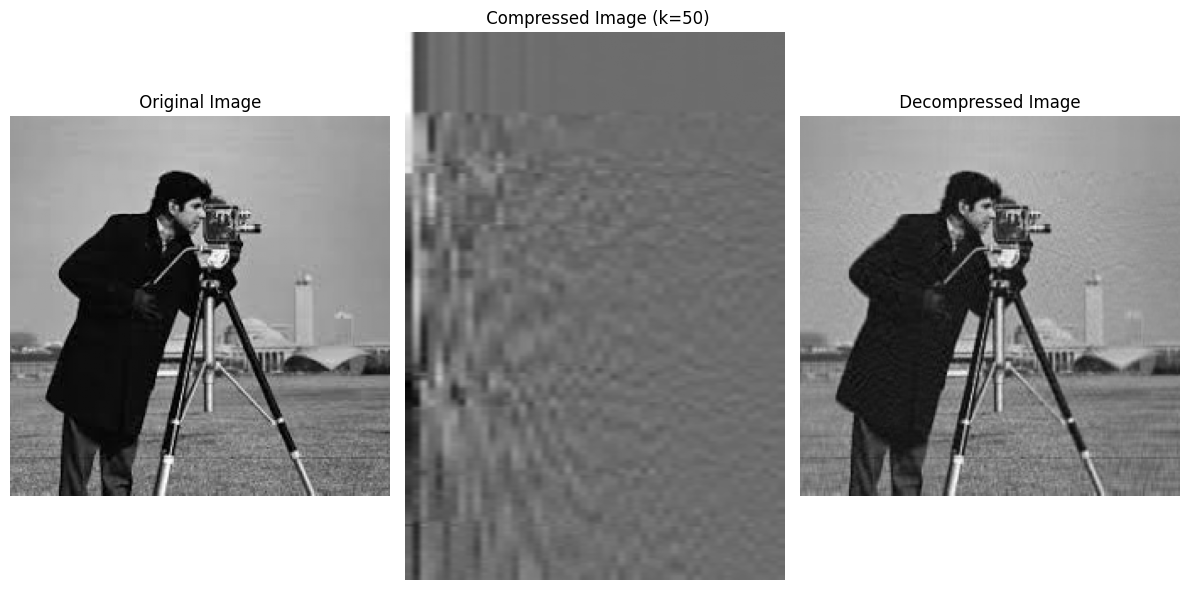

In [ ]:
plt . figure ( figsize =(12 , 6) )
# Original Image
plt . subplot (1 , 3 , 1)
plt.imshow ( image_array , cmap ="gray")
plt . title (" Original Image ")
plt . axis ("off")
# Compressed Representation
plt . subplot (1 , 3 , 2)
plt . imshow ( compressed_data , cmap ="gray", aspect ="auto")
plt . title ( f" Compressed Image (k={k})")
plt . axis ("off")
# Decompressed Image
plt . subplot (1 , 3 , 3)
plt . imshow ( decompressed_data , cmap ="gray")
plt . title (" Decompressed Image ")
plt . axis ("off")
plt . tight_layout ()
plt . show ()